In [1]:
# ==============================
# INSTALL REQUIRED LIBRARIES
# ==============================
!pip -q install transformers datasets scikit-learn seaborn tqdm

# ==============================
# IMPORT LIBRARIES
# ==============================
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

In [2]:
# ==============================
# SET SEED & DEVICE
# ==============================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# ==============================
# DATA LOADING
# ==============================
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [4]:
# ==============================
#   DATA PREPROCESSING
#  Clean text
#  Handle missing values
# ==============================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df = train_df.dropna()
test_df = test_df.dropna()

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [5]:
# ==============================
#  DATA SPLITTING
# Train / Validation / Test
# ==============================
train_full, val_full = train_test_split(
    train_df, test_size=0.2, stratify=train_df["label"], random_state=42
)

# Small subset (fast execution)
train_small = train_full.sample(n=1500, random_state=42)
val_small   = val_full.sample(n=300, random_state=42)
test_small  = test_df.sample(n=300, random_state=42)

train_small = train_small.reset_index(drop=True)
val_small   = val_small.reset_index(drop=True)
test_small  = test_small.reset_index(drop=True)

In [6]:
# ==============================
# TOKENIZATION
# ==============================
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 1
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [7]:
# ==============================
# PREPARE PYTORCH DATASET
# ==============================
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

In [8]:
# ==============================
# CREATE DATALOADERS
# ==============================
train_dataset = IMDBDataset(train_small["clean_text"].tolist(), train_small["label"].tolist())
val_dataset   = IMDBDataset(val_small["clean_text"].tolist(), val_small["label"].tolist())
test_dataset  = IMDBDataset(test_small["clean_text"].tolist(), test_small["label"].tolist())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [9]:
# ==============================
# HELPER FUNCTIONS
# ==============================
def create_model(name):
    return AutoModelForSequenceClassification.from_pretrained(name, num_labels=2)

def freeze_bert(model):
    for p in model.bert.parameters():
        p.requires_grad = False

def unfreeze_last2(model):
    for p in model.bert.parameters():
        p.requires_grad = False
    for layer in model.bert.encoder.layer[-2:]:
        for p in layer.parameters():
            p.requires_grad = True

def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()

        if scheduler:
            scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].numpy()
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            logits = outputs.logits
            p = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(p)
            true.extend(labels)

    return (
        accuracy_score(true, preds),
        precision_score(true, preds),
        recall_score(true, preds),
        f1_score(true, preds),
        confusion_matrix(true, preds)
    )

In [10]:
# ==============================
# EXPERIMENT 1:
# Freeze BERT
# ==============================
model1 = create_model(MODEL_NAME).to(device)
freeze_bert(model1)

optimizer1 = AdamW(filter(lambda p: p.requires_grad, model1.parameters()), lr=LR)

train_one_epoch(model1, train_loader, optimizer1)

acc1, p1, r1, f1_1, cm1 = evaluate(model1, test_loader)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/94 [00:00<?, ?it/s]

In [11]:
# ==============================
# EXPERIMENT 2:
# Last 2 Layers
# ==============================
model2 = create_model(MODEL_NAME).to(device)
unfreeze_last2(model2)

optimizer2 = AdamW(filter(lambda p: p.requires_grad, model2.parameters()), lr=LR)

train_one_epoch(model2, train_loader, optimizer2)

acc2, p2, r2, f1_2, cm2 = evaluate(model2, test_loader)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/94 [00:00<?, ?it/s]

In [12]:
# ==============================
# BONUS:
# DistilBERT + Scheduler
# ==============================
model3 = create_model("distilbert-base-uncased").to(device)

optimizer3 = AdamW(model3.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer3, num_warmup_steps=0, num_training_steps=total_steps
)

train_one_epoch(model3, train_loader, optimizer3, scheduler)

acc3, p3, r3, f1_3, cm3 = evaluate(model3, test_loader)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/94 [00:00<?, ?it/s]

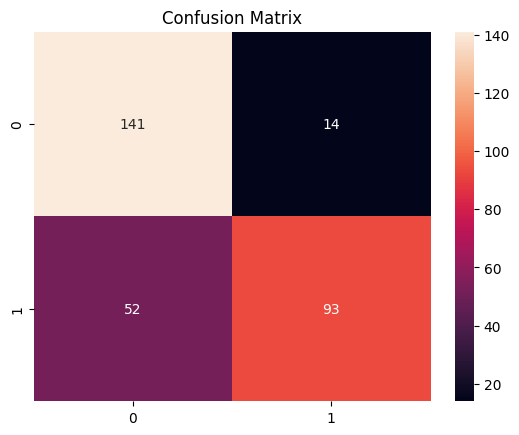

In [13]:
# ==============================
#  CONFUSION MATRIX
# ==============================
sns.heatmap(cm2, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [14]:
# ==============================
# COMPARISON
# ==============================
results = pd.DataFrame({
    "Model": ["Frozen", "Last2", "DistilBERT"],
    "Accuracy": [acc1, acc2, acc3],
    "Precision": [p1, p2, p3],
    "Recall": [r1, r2, r3],
    "F1": [f1_1, f1_2, f1_3]
})

print(results)

        Model  Accuracy  Precision    Recall        F1
0      Frozen  0.573333   0.551515  0.627586  0.587097
1       Last2  0.780000   0.869159  0.641379  0.738095
2  DistilBERT  0.816667   0.816901  0.800000  0.808362



**# FINAL ANALYSIS**



Experiment 1:
Only classifier trained → lower performance

Experiment 2:
Last 2 layers trained → better performance

Bonus:
DistilBERT is faster and efficient

Conclusion:
Fine-tuning improves model performance significantly.


# **Pipeline Flow:**

Raw Data → Preprocessing → Tokenization → Training → Evaluation → Comparison